In [8]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.geodetics.base import locations2degrees, degrees2kilometers
import os
import seisbench.models as sbm

In [2]:
"""
Download seismic waveform data from stations within 30 km of a seismic event.

Requirements:
    pip install obspy

Usage:
    Edit the EVENT parameters below and run: python download_seismic_data.py
"""



#	2024-02-10 20:03:23
# 2024-02-10 20:05:13

# ─────────────────────────────────────────────
# EVENT PARAMETERS — edit these
# ─────────────────────────────────────────────
EVENT_LAT   = 46.8406    # degrees North
EVENT_LON   = -121.7499  # degrees East (use negative for West)
START_TIME  = UTCDateTime("2024-02-10T20:03:00")
END_TIME    = UTCDateTime("2024-02-10T20:06:00")

MAX_RADIUS_KM  = 30       # km radius around event
CHANNEL        = "HH?,BH?,EH?"   # channel codes to request (wildcards OK)
NETWORK        = "*"      # network filter ("*" = all)
OUTPUT_DIR     = "waveforms"      # folder for downloaded miniseed files

# FDSN data centres to query (tried in order)
FDSN_CLIENTS   = ["IRIS", "NCEDC", "SCEDC"]
# ─────────────────────────────────────────────


def km_to_degrees(km):
    """Convert kilometres to decimal degrees (approximate)."""
    return km / 111.195


def download_data():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    max_radius_deg = km_to_degrees(MAX_RADIUS_KM)

    all_stations = []

    for client_name in FDSN_CLIENTS:
        print(f"\n→ Querying {client_name} for stations within {MAX_RADIUS_KM} km …")
        try:
            client = Client(client_name)
            inventory = client.get_stations(
                latitude=EVENT_LAT,
                longitude=EVENT_LON,
                maxradius=max_radius_deg,
                starttime=START_TIME,
                endtime=END_TIME,
                network=NETWORK,
                channel=CHANNEL,
                level="channel",
            )
        except Exception as e:
            print(f"  Could not retrieve station inventory from {client_name}: {e}")
            continue

        if len(inventory) == 0:
            print(f"  No stations found at {client_name}.")
            continue

        print(f"  Found {sum(len(n) for n in inventory)} networks with stations.")

        # Collect unique (network, station, location, channel) tuples
        for network in inventory:
            for station in network:
                dist_deg = locations2degrees(
                    EVENT_LAT, EVENT_LON,
                    station.latitude, station.longitude
                )
                dist_km = degrees2kilometers(dist_deg)

                if dist_km <= MAX_RADIUS_KM:
                    for channel in station:
                        all_stations.append({
                            "client_name": client_name,
                            "client":      client,
                            "network":     network.code,
                            "station":     station.code,
                            "location":    channel.location_code,
                            "channel":     channel.code,
                            "latitude":    station.latitude,
                            "longitude":   station.longitude,
                            "distance_km": dist_km,
                        })

    if not all_stations:
        print("\nNo stations found within the search radius. Try a different FDSN client or larger radius.")
        return

    # De-duplicate by (network, station, location, channel)
    seen = set()
    unique_stations = []
    for s in all_stations:
        key = (s["network"], s["station"], s["location"], s["channel"])
        if key not in seen:
            seen.add(key)
            unique_stations.append(s)

    print(f"\n{'─'*60}")
    print(f"Total unique channels within {MAX_RADIUS_KM} km: {len(unique_stations)}")
    print(f"{'─'*60}")

    downloaded, failed = 0, 0

    for s in unique_stations:
        nslc = f"{s['network']}.{s['station']}.{s['location']}.{s['channel']}"
        fname = os.path.join(
            OUTPUT_DIR,
            f"{nslc}.{START_TIME.strftime('%Y%m%dT%H%M%S')}.mseed"
        )

        print(f"  Downloading {nslc}  ({s['distance_km']:.1f} km) … ", end="", flush=True)

        try:
            st = s["client"].get_waveforms(
                network=s["network"],
                station=s["station"],
                location=s["location"],
                channel=s["channel"],
                starttime=START_TIME,
                endtime=END_TIME,
            )
            st.write(fname, format="MSEED")
            print(f"✓  saved → {fname}")
            downloaded += 1

        except Exception as e:
            print(f"✗  failed: {e}")
            failed += 1

    print(f"\n{'='*60}")
    print(f"Download complete: {downloaded} succeeded, {failed} failed.")
    print(f"Files saved to: {os.path.abspath(OUTPUT_DIR)}/")
    print(f"{'='*60}")




In [3]:
if __name__ == "__main__":
    download_data()


→ Querying IRIS for stations within 30 km …
  Found 32 networks with stations.

→ Querying NCEDC for stations within 30 km …
  Could not retrieve station inventory from NCEDC: No data available for request.
HTTP Status code: 204
Detailed response of server:



→ Querying SCEDC for stations within 30 km …
  Could not retrieve station inventory from SCEDC: No data available for request.
HTTP Status code: 204
Detailed response of server:



────────────────────────────────────────────────────────────
Total unique channels within 30 km: 92
────────────────────────────────────────────────────────────


HTTP Status code: 204
Detailed response of server:


HTTP Status code: 204
Detailed response of server:


HTTP Status code: 204
Detailed response of server:



Download complete: 89 succeeded, 3 failed.
Files saved to: /home/ak287/pnw_seismic_event_detection/notebooks/waveforms/


In [4]:
"""
Collect Z-component traces from already downloaded MiniSEED files
in the waveforms/ directory into a single ObsPy Stream.

Requires: pip install obspy
"""

from obspy import Stream, read
import glob
import os

WAVEFORMS_DIR = "waveforms"   # folder containing downloaded .mseed files


def get_z_stream(waveforms_dir: str = WAVEFORMS_DIR) -> Stream:
    """
    Read all MiniSEED files in waveforms_dir and return a Stream
    containing only the Z-component traces.
    """
    pattern = os.path.join(waveforms_dir, "*.mseed")
    files = sorted(glob.glob(pattern))

    if not files:
        print(f"No .mseed files found in '{waveforms_dir}/'")
        return Stream()

    print(f"Found {len(files)} file(s) in '{waveforms_dir}/' — filtering Z components ...\n")

    z_stream = Stream()

    for fpath in files:
        try:
            st = read(fpath)
            z_traces = st.select(component="Z")   # keeps *Z channels only
            if z_traces:
                z_stream += z_traces
                for tr in z_traces:
                    print(f"  +  {tr.id}")
            # silently skip files with no Z component
        except Exception as e:
            print(f"  x  {fpath}: {e}")

    return z_stream




"""
Preprocess the Z-component stream:
  1. Resample to 50 Hz
  2. Detrend (demean + linear)
  3. Taper (1%)
  4. Bandpass filter (1–5 Hz)

Requires: pip install obspy
"""

from obspy import Stream, read
import glob
import os

WAVEFORMS_DIR = "waveforms"
TARGET_SAMPLING_RATE = 50.0   # Hz
TAPER_PERCENT        = 0.01   # 1 %
FILTER_FREQMIN       = 1.0    # Hz
FILTER_FREQMAX       = 5.0    # Hz


def get_z_stream(waveforms_dir: str = WAVEFORMS_DIR) -> Stream:
    """Read Z-component traces from downloaded MiniSEED files."""
    files = sorted(glob.glob(os.path.join(waveforms_dir, "*.mseed")))
    if not files:
        print(f"No .mseed files found in '{waveforms_dir}/'")
        return Stream()

    z_stream = Stream()
    for fpath in files:
        try:
            st = read(fpath)
            z_traces = st.select(component="Z")
            if z_traces:
                z_stream += z_traces
        except Exception as e:
            print(f"  Could not read {fpath}: {e}")

    return z_stream


def preprocess(stream: Stream) -> Stream:
    """
    Apply standard preprocessing to a Z-component stream in-place.

    Steps
    -----
    1. Resample  → TARGET_SAMPLING_RATE Hz
    2. Detrend   → remove mean, then linear trend
    3. Taper     → cosine taper (TAPER_PERCENT of trace length at each end)
    4. Bandpass  → FILTER_FREQMIN – FILTER_FREQMAX Hz (zero-phase, 4-corner)
    """
    if not stream:
        print("Stream is empty — nothing to preprocess.")
        return stream

    print(f"Preprocessing {len(stream)} trace(s) …\n")

    for tr in stream:
        print(f"  {tr.id}  (fs={tr.stats.sampling_rate} Hz, {tr.stats.npts} samples)")

        # 1. Resample
        if tr.stats.sampling_rate != TARGET_SAMPLING_RATE:
            tr.resample(TARGET_SAMPLING_RATE)

        # 2. Detrend — demean first, then remove linear trend
        tr.detrend("demean")
        tr.detrend("linear")

        # 3. Taper
        tr.taper(max_percentage=TAPER_PERCENT, type="cosine")

        # 4. Bandpass filter (zero-phase to avoid phase distortion)
        tr.filter(
            "bandpass",
            freqmin=FILTER_FREQMIN,
            freqmax=FILTER_FREQMAX,
            corners=4,
            zerophase=True,
        )

        print(f"       → resampled to {tr.stats.sampling_rate} Hz, "
              f"detrended, tapered, bandpass {FILTER_FREQMIN}–{FILTER_FREQMAX} Hz")

    print(f"\nDone. Stream contains {len(stream)} processed trace(s).")
    return stream


In [5]:
"""
Preprocess the Z-component stream:
  1. Resample to 50 Hz
  2. Detrend (demean + linear)
  3. Taper (1%)
  4. Bandpass filter (1–5 Hz)

Requires: pip install obspy
"""

from obspy import Stream, read
from obspy.clients.fdsn import Client
from obspy.geodetics.base import locations2degrees, degrees2kilometers
import glob
import os

WAVEFORMS_DIR = "waveforms"

# ── Event location (needed for distance sorting) ──
EVENT_LAT = 46.8406
EVENT_LON = -121.7499

# FDSN client to fetch station coordinates
FDSN_CLIENTS = ["IRIS", "NCEDC", "SCEDC"]
TARGET_SAMPLING_RATE = 50.0   # Hz
TAPER_PERCENT        = 0.01   # 1 %
FILTER_FREQMIN       = 1.0    # Hz
FILTER_FREQMAX       = 5.0    # Hz


def get_z_stream(waveforms_dir: str = WAVEFORMS_DIR) -> Stream:
    """Read Z-component traces from downloaded MiniSEED files."""
    files = sorted(glob.glob(os.path.join(waveforms_dir, "*.mseed")))
    if not files:
        print(f"No .mseed files found in '{waveforms_dir}/'")
        return Stream()

    z_stream = Stream()
    for fpath in files:
        try:
            st = read(fpath)
            z_traces = st.select(component="Z")
            if z_traces:
                z_stream += z_traces
        except Exception as e:
            print(f"  Could not read {fpath}: {e}")

    return z_stream


def preprocess(stream: Stream) -> Stream:
    """
    Apply standard preprocessing to a Z-component stream in-place.

    Steps
    -----
    1. Resample  → TARGET_SAMPLING_RATE Hz
    2. Detrend   → remove mean, then linear trend
    3. Taper     → cosine taper (TAPER_PERCENT of trace length at each end)
    4. Bandpass  → FILTER_FREQMIN – FILTER_FREQMAX Hz (zero-phase, 4-corner)
    """
    if not stream:
        print("Stream is empty — nothing to preprocess.")
        return stream

    print(f"Preprocessing {len(stream)} trace(s) …\n")

    for tr in stream:
        print(f"  {tr.id}  (fs={tr.stats.sampling_rate} Hz, {tr.stats.npts} samples)")

        # 1. Resample
        if tr.stats.sampling_rate != TARGET_SAMPLING_RATE:
            tr.resample(TARGET_SAMPLING_RATE)

        # 2. Detrend — demean first, then remove linear trend
        tr.detrend("demean")
        tr.detrend("linear")

        # 3. Taper
        tr.taper(max_percentage=TAPER_PERCENT, type="cosine")

        # 4. Bandpass filter (zero-phase to avoid phase distortion)
        tr.filter(
            "bandpass",
            freqmin=FILTER_FREQMIN,
            freqmax=FILTER_FREQMAX,
            corners=4,
            zerophase=True,
        )

        print(f"       → resampled to {tr.stats.sampling_rate} Hz, "
              f"detrended, tapered, bandpass {FILTER_FREQMIN}–{FILTER_FREQMAX} Hz")

    print(f"\nDone. Stream contains {len(stream)} processed trace(s).")
    return stream


def sort_by_distance(stream: Stream) -> Stream:
    """
    Attach epicentral distance (km) to each trace's stats and return
    the stream sorted nearest → farthest.

    Strategy
    --------
    1. If tr.stats.distance_km already exists (set during download), use it.
    2. Otherwise query FDSN for station coordinates and compute the distance.
    3. Traces whose coordinates cannot be resolved are placed at the end.
    """
    if not stream:
        return stream

    print("\nSorting traces by event-station distance …")

    # Collect stations that still need coordinates
    missing = [tr for tr in stream if not hasattr(tr.stats, "distance_km")]

    if missing:
        # Build a set of unique (network, station) pairs to query
        net_sta = {(tr.stats.network, tr.stats.station) for tr in missing}
        coord_map = {}  # (net, sta) → (lat, lon)

        for client_name in FDSN_CLIENTS:
            if not net_sta:
                break
            try:
                client = Client(client_name)
                for net, sta in list(net_sta):
                    try:
                        inv = client.get_stations(network=net, station=sta, level="station")
                        st_obj = inv[0][0]
                        coord_map[(net, sta)] = (st_obj.latitude, st_obj.longitude)
                        net_sta.discard((net, sta))
                    except Exception:
                        pass
            except Exception:
                pass

        # Attach distances
        for tr in missing:
            key = (tr.stats.network, tr.stats.station)
            if key in coord_map:
                lat, lon = coord_map[key]
                dist_km = degrees2kilometers(
                    locations2degrees(EVENT_LAT, EVENT_LON, lat, lon)
                )
                tr.stats.distance_km = dist_km
            else:
                tr.stats.distance_km = float("inf")   # unknown → sort to end
                print(f"  Could not resolve coordinates for {tr.id} — placed at end.")

    # Sort stream in-place by distance
    stream.traces.sort(key=lambda tr: tr.stats.distance_km)

    print(f"  {'Station':<12} {'Distance (km)':>15}")
    print(f"  {'-'*12} {'-'*15}")
    for tr in stream:
        dist = tr.stats.distance_km
        dist_str = f"{dist:.1f}" if dist != float('inf') else "unknown"
        print(f"  {tr.stats.station:<12} {dist_str:>15}")

    return stream


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # Load Z components
    stream = get_z_stream()

    if not stream:
        print("No Z-component data found. Run download_seismic_data.py first.")
    else:
        print(f"Loaded {len(stream)} Z-component trace(s).\n{'='*60}")

        # Preprocess
        processed = preprocess(stream)

        # Sort by event-station distance
        processed = sort_by_distance(processed)

        print(f"\n{'='*60}")
        print(processed)

        # Uncomment to plot:
        # processed.plot()

        # Uncomment to save:
        # processed.write("z_processed.mseed", format="MSEED")

Loaded 36 Z-component trace(s).
Preprocessing 36 trace(s) …

  CC.ARAT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CARB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.COPP..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CRBN..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GNOB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GTWY..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAUT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAVK..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.MILD..BHZ  (fs=50.0 Hz

Preprocessing 36 trace(s) …

  CC.ARAT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CARB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.COPP..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CRBN..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GNOB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GTWY..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAUT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAVK..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.MILD..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampl

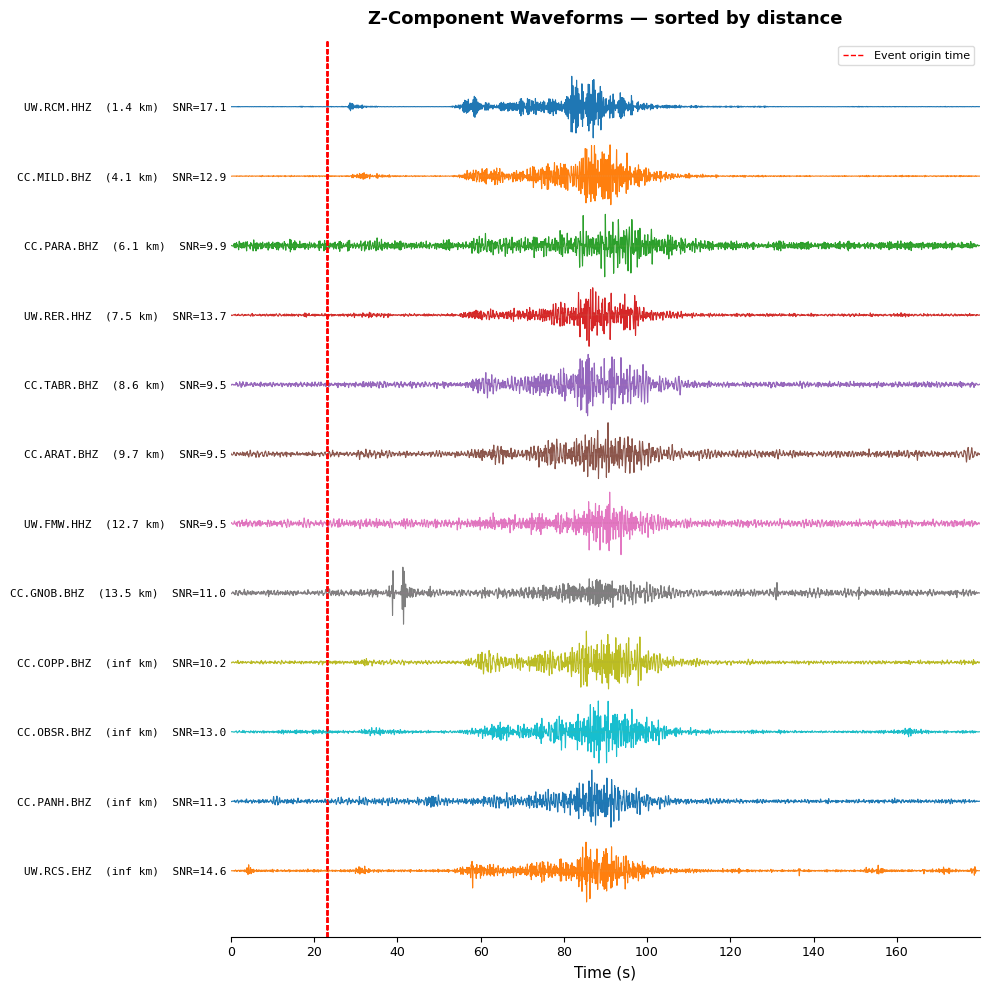

In [6]:
"""
Plot processed Z-component waveforms in a single figure.
- Figure size (15, 10)
- SNR filter: max(envelope) / mean(envelope) >= SNR_THRESHOLD
- One axis, traces stacked vertically offset by row index
- Each trace a different color
- Amplitude normalised by per-trace maximum
- Y-tick labels fixed to exactly match each trace's baseline offset:
    network.station.channel  (distance km)  SNR=XX.X
- Nearest station at top, farthest at bottom

Requires: pip install obspy matplotlib scipy
"""

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.signal import hilbert

# ─────────────────────────────────────────────
FIGURE_TITLE  = "Z-Component Waveforms — sorted by distance"
OUTPUT_FILE   = "z_waveforms.png"   # None → interactive only
DPI           = 150
TRACE_SCALE   = 0.45    # half-height of each normalised waveform (0–1)
SNR_THRESHOLD = 8.0     # min max(envelope)/mean(envelope) to keep a trace
# ─────────────────────────────────────────────


def compute_snr(trace) -> float:
    """SNR = max(envelope) / mean(envelope) using the Hilbert envelope."""
    envelope = np.abs(hilbert(trace.data))
    mean_env = np.mean(envelope)
    if mean_env == 0:
        return 0.0
    return float(np.max(envelope) / mean_env)


def deduplicate_by_station(stream):
    """
    For stations with multiple Z-component traces (different channels or
    location codes), keep only the one with the highest SNR.
    Returns a new Stream with at most one trace per network.station pair.
    """
    from obspy import Stream

    # Ensure SNR is computed on every trace first
    for tr in stream:
        if not hasattr(tr.stats, "snr"):
            tr.stats.snr = compute_snr(tr)

    # Group by (network, station) and keep best SNR
    best = {}   # (net, sta) → trace
    for tr in stream:
        key = (tr.stats.network, tr.stats.station)
        if key not in best or tr.stats.snr > best[key].stats.snr:
            best[key] = tr

    deduped = Stream(list(best.values()))

    removed = len(stream) - len(deduped)
    if removed:
        print(f"\nDeduplicated: removed {removed} lower-SNR duplicate(s) "
              f"({len(deduped)} trace(s) remaining).")

    return deduped


def filter_by_snr(stream, threshold: float = SNR_THRESHOLD):
    """Return a Stream containing only traces with SNR >= threshold."""
    from obspy import Stream
    good = Stream()
    rejected = []
    for tr in stream:
        snr = compute_snr(tr)
        tr.stats.snr = snr          # attach for label use later
        if snr >= threshold:
            good += tr
        else:
            rejected.append((tr.id, snr))

    print(f"\nSNR filter (threshold={threshold}):")
    print(f"  Kept    : {len(good)} trace(s)")
    print(f"  Rejected: {len(rejected)} trace(s)")
    for tid, snr in rejected:
        print(f"    {tid}  SNR={snr:.2f}")

    return good


def plot_z_stream(stream, title: str = FIGURE_TITLE, output_file: str = OUTPUT_FILE):
    """
    Plot all traces in `stream` on a single axes, stacked nearest → farthest.
    Applies SNR filtering before plotting.
    Stream must already be sorted by distance_km.
    """
    # ── Deduplicate: one trace per station (keep highest SNR) ──
    stream = deduplicate_by_station(stream)

    # ── SNR filter ──
    stream = filter_by_snr(stream)

    if not stream:
        print("No traces passed the SNR filter — nothing to plot.")
        return

    n = len(stream)
    if n <= 20:
        colors = cm.tab20(np.linspace(0, 1, n))
    else:
        colors = colors = [
    "#DC143C",  # Crimson
    "#1E90FF",  # Dodger Blue
    "#228B22",  # Forest Green
    "#FF8C00",  # Dark Orange
    "#9370DB",  # Medium Purple
    "#008080",  # Teal
    "#FF69B4",  # Hot Pink
    "#FFD700",  # Gold
    "#6A5ACD",  # Slate Blue
    "#FF6347",  # Coral
    "#32CD32",  # Lime Green
    "#00BFFF",  # Deep Sky Blue
    "#8B4513",  # Saddle Brown
    "#BA55D3",  # Medium Orchid
    "#00FF7F",  # Spring Green
    "#B22222",  # Firebrick
    "#4682B4",  # Steel Blue
    "#B8860B",  # Dark Goldenrod
    "#40E0D0",  # Turquoise
    "#6B8E23",  # Olive Drab
    "#FF4500",  # Orange Red
    "#5F9EA0",  # Cadet Blue
    "#9400D3",  # Dark Violet
]

    #colors = ['black']*23
    fig, ax = plt.subplots(figsize=(10, 10))

    # Offsets: trace 0 (nearest) at top → highest offset value
    offsets = list(range(n - 1, -1, -1))   # [n-1, n-2, ..., 0]

    ytick_positions = []
    ytick_labels    = []

    for tr, color, offset in zip(stream, colors, offsets):
        times = tr.times()
        peak  = np.max(np.abs(tr.data))
        data  = tr.data / (peak + 1e-10) * TRACE_SCALE

        ax.plot(times, data + offset,  linewidth=0.8)
        ax.axhline(offset, color=color, linewidth=0.3, linestyle="--", alpha=0.35)
        ax.axvline(23, color = 'red', linewidth = 1, linestyle = '--')

        # Y-tick label sits exactly at `offset` (the baseline of this trace)
        st       = tr.stats
        dist     = getattr(st, "distance_km", None)
        snr      = getattr(st, "snr", None)
        dist_str = f"{dist:.1f} km" if dist is not None else "? km"
        snr_str  = f"  SNR={snr:.1f}" if snr is not None else ""
        label    = f"{st.network}.{st.station}.{st.channel}  ({dist_str}){snr_str}"

        ytick_positions.append(offset)
        ytick_labels.append(label)

    # Set ticks explicitly — one tick per trace, exactly at its offset
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=8, fontfamily="monospace")
    ax.yaxis.set_tick_params(length=0)   # hide tick marks, keep labels
    
    # ── Legend for STA/LTA pick markers ──
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color="red", linewidth= 1, linestyle="--",  label="Event origin time"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.7)
    
    

    ax.set_ylim(-0.5 - TRACE_SCALE, n - 0.5 + TRACE_SCALE)
    ax.set_xlim(stream[0].times()[0], stream[0].times()[-1])
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=DPI, bbox_inches="tight")
        print(f"\nPlot saved → {output_file}")

    plt.show()
    return fig


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
if __name__ == "__main__":

    stream    = get_z_stream()
    processed = preprocess(stream)
    sorted_st = sort_by_distance(processed)

    plot_z_stream(sorted_st)

## Goal - 
 - 1) Plot the processed waveforms associated with that Icefall event. 
 - 2) Show the performance of the STA/LTA picker
 - 3) Show the performance of the deep learning picker
 - 4) Show the performance of the Kurtosis based picker

And saying that none of these pickers are perfect, cant work for surface event so we need enveloc

## Plotting STA/LTA

Preprocessing 36 trace(s) …

  CC.ARAT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CARB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.COPP..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CRBN..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GNOB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GTWY..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAUT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAVK..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.MILD..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampl


Plot saved → z_waveforms.png


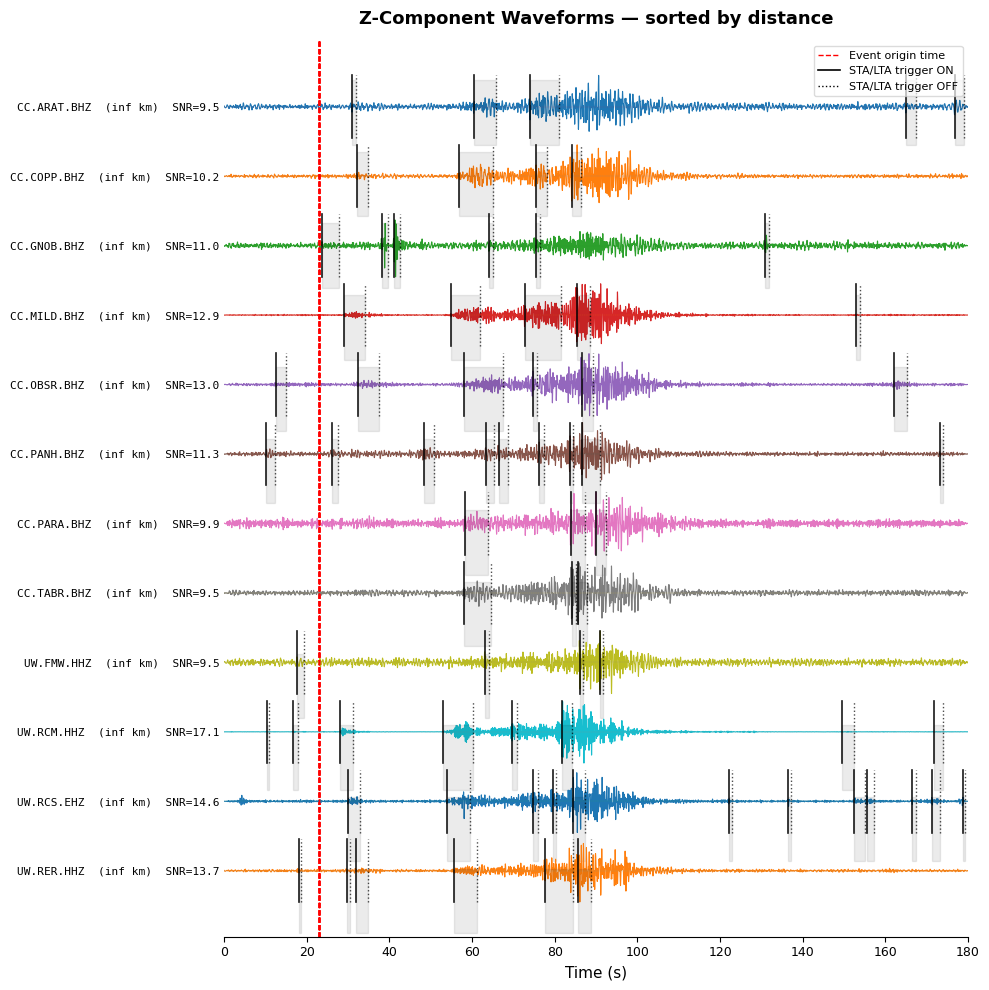

In [7]:
"""
Plot processed Z-component waveforms in a single figure.
- Figure size (15, 10)
- SNR filter: max(envelope) / mean(envelope) >= SNR_THRESHOLD
- One axis, traces stacked vertically offset by row index
- Each trace a different color
- Amplitude normalised by per-trace maximum
- Y-tick labels fixed to exactly match each trace's baseline offset:
    network.station.channel  (distance km)  SNR=XX.X
- Nearest station at top, farthest at bottom

Requires: pip install obspy matplotlib scipy
"""

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.signal import hilbert
from obspy.signal.trigger import classic_sta_lta, trigger_onset

# ─────────────────────────────────────────────
FIGURE_TITLE  = "Z-Component Waveforms — sorted by distance"
OUTPUT_FILE   = "z_waveforms.png"   # None → interactive only
DPI           = 150
TRACE_SCALE   = 0.45    # half-height of each normalised waveform (0–1)
SNR_THRESHOLD = 8     # min max(envelope)/mean(envelope) to keep a trace

# ── STA/LTA parameters ──
STA_SEC    = 0.5    # short-term average window (seconds)
LTA_SEC    = 10.0   # long-term average window (seconds)
TRIGGER_ON  = 4.0   # STA/LTA ratio to declare trigger ON
TRIGGER_OFF = 0.5   # STA/LTA ratio to declare trigger OFF

CUSTOM_COLORS = [
    "#DC143C", "#1E90FF", "#228B22", "#FF8C00", "#9370DB",
    "#008080", "#FF69B4", "#FFD700", "#6A5ACD", "#FF6347",
    "#32CD32", "#00BFFF", "#8B4513", "#BA55D3", "#00FF7F",
    "#B22222", "#4682B4", "#B8860B", "#40E0D0", "#6B8E23",
    "#FF4500", "#5F9EA0", "#9400D3",
]
# ─────────────────────────────────────────────


def compute_snr(trace) -> float:
    """SNR = max(envelope) / mean(envelope) using the Hilbert envelope."""
    envelope = np.abs(hilbert(trace.data))
    mean_env = np.mean(envelope)
    if mean_env == 0:
        return 0.0
    return float(np.max(envelope) / mean_env)


def deduplicate_by_station(stream):
    """
    For stations with multiple Z-component traces (different channels or
    location codes), keep only the one with the highest SNR.
    Returns a new Stream with at most one trace per network.station pair.
    """
    from obspy import Stream

    # Ensure SNR is computed on every trace first
    for tr in stream:
        if not hasattr(tr.stats, "snr"):
            tr.stats.snr = compute_snr(tr)

    # Group by (network, station) and keep best SNR
    best = {}   # (net, sta) → trace
    for tr in stream:
        key = (tr.stats.network, tr.stats.station)
        if key not in best or tr.stats.snr > best[key].stats.snr:
            best[key] = tr

    deduped = Stream(list(best.values()))

    removed = len(stream) - len(deduped)
    if removed:
        print(f"\nDeduplicated: removed {removed} lower-SNR duplicate(s) "
              f"({len(deduped)} trace(s) remaining).")

    return deduped


def filter_by_snr(stream, threshold: float = SNR_THRESHOLD):
    """Return a Stream containing only traces with SNR >= threshold."""
    from obspy import Stream
    good = Stream()
    rejected = []
    for tr in stream:
        snr = compute_snr(tr)
        tr.stats.snr = snr          # attach for label use later
        if snr >= threshold:
            good += tr
        else:
            rejected.append((tr.id, snr))

    print(f"\nSNR filter (threshold={threshold}):")
    print(f"  Kept    : {len(good)} trace(s)")
    print(f"  Rejected: {len(rejected)} trace(s)")
    for tid, snr in rejected:
        print(f"    {tid}  SNR={snr:.2f}")

    return good


def compute_sta_lta_picks(trace):
    """
    Run classic STA/LTA on a trace and return onset times (seconds
    relative to trace start) where the characteristic function crosses
    TRIGGER_ON (pick) and TRIGGER_OFF (end).

    Returns list of (on_sec, off_sec) tuples.
    """
    fs   = trace.stats.sampling_rate
    nsta = int(STA_SEC * fs)
    nlta = int(LTA_SEC * fs)

    if len(trace.data) < nlta + nsta:
        return []

    cft    = classic_sta_lta(trace.data, nsta, nlta)
    onsets = trigger_onset(cft, TRIGGER_ON, TRIGGER_OFF)

    picks = []
    for on, off in onsets:
        on_sec  = on  / fs
        off_sec = off / fs
        picks.append((on_sec, off_sec))
    return picks


def plot_z_stream(stream, title: str = FIGURE_TITLE, output_file: str = OUTPUT_FILE):
    """
    Plot all traces in `stream` on a single axes, stacked nearest → farthest.
    Applies SNR filtering before plotting.
    Stream must already be sorted by distance_km.
    """
    # ── Deduplicate: one trace per station (keep highest SNR) ──
    stream = deduplicate_by_station(stream)

    # ── SNR filter ──
    stream = filter_by_snr(stream)

    if not stream:
        print("No traces passed the SNR filter — nothing to plot.")
        return

    n = len(stream)
    # Cycle through custom colors
    colors = [CUSTOM_COLORS[i % len(CUSTOM_COLORS)] for i in range(n)]

    fig, ax = plt.subplots(figsize=(10, 10))

    # Offsets: trace 0 (nearest) at top → highest offset value
    offsets = list(range(n - 1, -1, -1))   # [n-1, n-2, ..., 0]

    ytick_positions = []
    ytick_labels    = []

    for tr, color, offset in zip(stream, colors, offsets):
        times = tr.times()
        peak  = np.max(np.abs(tr.data))
        data  = tr.data / (peak + 1e-10) * TRACE_SCALE

        ax.plot(times, data + offset, linewidth=0.8)
        ax.axhline(offset, color=color, linewidth=0.3, linestyle="--", alpha=0.35)
        
        ax.axvline(23, color = 'red', linewidth = 1, linestyle = '--')

        # ── STA/LTA picks ──
        picks = compute_sta_lta_picks(tr)
        for on_sec, off_sec in picks:
            # Trigger ON — solid black line spanning ±TRACE_SCALE around baseline
            ax.plot([on_sec, on_sec],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="black", linewidth=1.2, linestyle="-", alpha=0.9, zorder=3)
            # Trigger OFF — dashed black line spanning ±TRACE_SCALE around baseline
            ax.plot([off_sec, off_sec],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="black", linewidth=1.0, linestyle=":", alpha=0.7, zorder=3)
            # Shaded window between ON and OFF
            ax.axvspan(on_sec, off_sec,
                       ymin=(offset - TRACE_SCALE + 0.5) / (n + 0.5),
                       ymax=(offset + TRACE_SCALE + 0.5) / (n + 0.5),
                       alpha=0.08, color="black", zorder=2)

        # Y-tick label sits exactly at `offset` (the baseline of this trace)
        st       = tr.stats
        dist     = getattr(st, "distance_km", None)
        snr      = getattr(st, "snr", None)
        dist_str = f"{dist:.1f} km" if dist is not None else "? km"
        snr_str  = f"  SNR={snr:.1f}" if snr is not None else ""
        label    = f"{st.network}.{st.station}.{st.channel}  ({dist_str}){snr_str}"

        ytick_positions.append(offset)
        ytick_labels.append(label)

    # Set ticks explicitly — one tick per trace, exactly at its offset
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=8, fontfamily="monospace")
    ax.yaxis.set_tick_params(length=0)   # hide tick marks, keep labels

    ax.set_ylim(-0.5 - TRACE_SCALE, n - 0.5 + TRACE_SCALE)
    ax.set_xlim(stream[0].times()[0], stream[0].times()[-1])
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)

    # ── Legend for STA/LTA pick markers ──
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color="red", linewidth= 1, linestyle="--",  label="Event origin time"),
        Line2D([0], [0], color="black", linewidth=1.2, linestyle="-",  label="STA/LTA trigger ON"),
        Line2D([0], [0], color="black", linewidth=1.0, linestyle=":",  label="STA/LTA trigger OFF"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.7)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=DPI, bbox_inches="tight")
        print(f"\nPlot saved → {output_file}")

    plt.show()
    return fig


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
if __name__ == "__main__":

    stream    = get_z_stream()
    processed = preprocess(stream)
    sorted_st = sort_by_distance(processed)

    plot_z_stream(sorted_st)

## Plotting deep learning picker results

In [9]:
# Various pre-trained weights for PhaseNet
# pn_model = sbm.PhaseNet.from_pretrained("ethz")
# pn_model = sbm.PhaseNet.from_pretrained("instance")
# pn_model = sbm.PhaseNet.from_pretrained("scedc")
pn_model = sbm.PhaseNet.from_pretrained("stead")
# pn_model = sbm.PhaseNet.from_pretrained("geofon")
# pn_model = sbm.PhaseNet.from_pretrained("neic")

# Various pre-trained weights for EQT
eqt_model = sbm.EQTransformer.from_pretrained("original")
#eqt_model = sbm.EQTransformer.from_pretrained("ethz")
# eqt_model = sbm.EQTransformer.from_pretrained("instance")
#eqt_model = sbm.EQTransformer.from_pretrained("scedc")
# eqt_model = sbm.EQTransformer.from_pretrained("stead")
# eqt_model = sbm.EQTransformer.from_pretrained("geofon")

# Various pre-trained weights for GPD
# gpd_model = sbm.GPD.from_pretrained("original")
# gpd_model = sbm.GPD.from_pretrained("ethz")
# gpd_model = sbm.GPD.from_pretrained("scedc")
gpd_model = sbm.GPD.from_pretrained("stead")
# gpd_model = sbm.GPD.from_pretrained("geofon")
# gpd_model = sbm.GPD.from_pretrained("neic")

Preprocessing 36 trace(s) …

  CC.ARAT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CARB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.COPP..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CRBN..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GNOB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GTWY..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAUT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAVK..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.MILD..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampl

/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)


  UW.RCM..HHZ: 4 P-pick(s), 3 S-pick(s)
  UW.RCS..EHZ: 0 P-pick(s), 1 S-pick(s)


/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)


  CC.MILD..BHZ: 2 P-pick(s), 1 S-pick(s)
  CC.PARA..BHZ: 0 P-pick(s), 0 S-pick(s)


...

  CC.PANH..BHZ: 1 P-pick(s), 0 S-pick(s)
  CC.TABR..BHZ: 1 P-pick(s), 1 S-pick(s)


/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)


  CC.ARAT..BHZ: 0 P-pick(s), 0 S-pick(s)
  UW.FMW..HHZ: 1 P-pick(s), 1 S-pick(s)
  CC.GNOB..BHZ: 0 P-pick(s), 1 S-pick(s)


/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)
/home/ak287/miniconda3/envs/surface/lib/python3.9/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (45) of bandpass is at or above Nyquist (25.0). Applying a high-pass instead.
  warnings.warn(msg)



Plot saved → z_waveforms.png


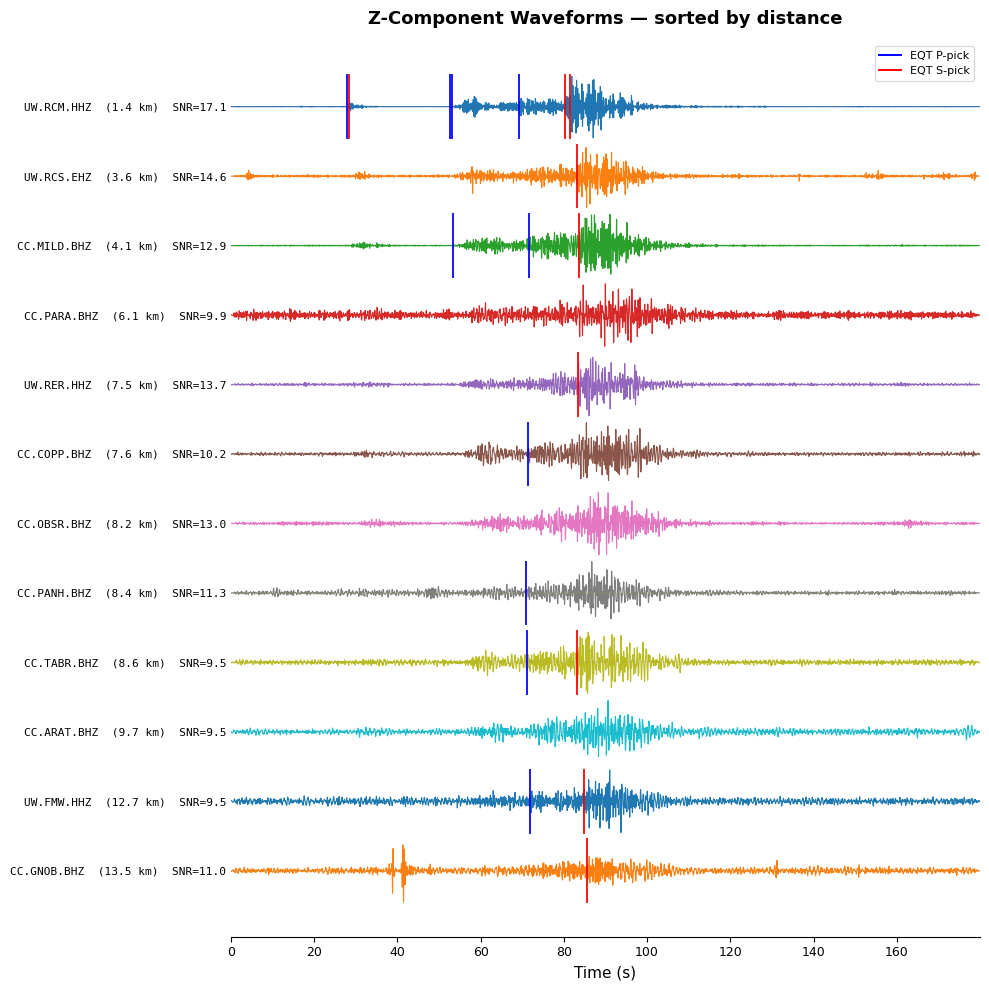

In [12]:
"""
Plot processed Z-component waveforms in a single figure with EQTransformer picks.
- Figure size (15, 10)
- SNR filter: max(envelope) / mean(envelope) >= SNR_THRESHOLD
- One axis, traces stacked vertically offset by row index
- Each trace a different color
- Amplitude normalised by per-trace maximum
- EQTransformer P and S picks plotted as vertical lines per trace
- Y-tick labels: network.station.channel  (distance km)  SNR=XX.X
- Nearest station at top, farthest at bottom

Requires: pip install obspy matplotlib scipy seisbench torch
"""

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.signal import hilbert
from obspy import Stream
import seisbench.models as sbm

# ─────────────────────────────────────────────
FIGURE_TITLE  = "Z-Component Waveforms — sorted by distance"
OUTPUT_FILE   = "z_waveforms.png"   # None → interactive only
DPI           = 150
TRACE_SCALE   = 0.45    # half-height of each normalised waveform (0–1)
SNR_THRESHOLD = 8.0     # min max(envelope)/mean(envelope) to keep a trace

# ── EQTransformer pick thresholds ──
EQT_P_THRESHOLD = 0.1   # minimum P-pick probability to plot
EQT_S_THRESHOLD = 0.1   # minimum S-pick probability to plot

CUSTOM_COLORS = [
    "#DC143C", "#1E90FF", "#228B22", "#FF8C00", "#9370DB",
    "#008080", "#FF69B4", "#FFD700", "#6A5ACD", "#FF6347",
    "#32CD32", "#00BFFF", "#8B4513", "#BA55D3", "#00FF7F",
    "#B22222", "#4682B4", "#B8860B", "#40E0D0", "#6B8E23",
    "#FF4500", "#5F9EA0", "#9400D3",
]
# ─────────────────────────────────────────────


def compute_snr(trace) -> float:
    """SNR = max(envelope) / mean(envelope) using the Hilbert envelope."""
    envelope = np.abs(hilbert(trace.data))
    mean_env = np.mean(envelope)
    if mean_env == 0:
        return 0.0
    return float(np.max(envelope) / mean_env)


def deduplicate_by_station(stream):
    """Keep only the highest-SNR trace per network.station pair."""
    for tr in stream:
        if not hasattr(tr.stats, "snr"):
            tr.stats.snr = compute_snr(tr)

    best = {}
    for tr in stream:
        key = (tr.stats.network, tr.stats.station)
        if key not in best or tr.stats.snr > best[key].stats.snr:
            best[key] = tr

    deduped = Stream(list(best.values()))
    removed = len(stream) - len(deduped)
    if removed:
        print(f"\nDeduplicated: removed {removed} lower-SNR duplicate(s) "
              f"({len(deduped)} trace(s) remaining).")
    return deduped


def filter_by_snr(stream, threshold: float = SNR_THRESHOLD):
    """Return a Stream containing only traces with SNR >= threshold."""
    good = Stream()
    rejected = []
    for tr in stream:
        snr = compute_snr(tr)
        tr.stats.snr = snr
        if snr >= threshold:
            good += tr
        else:
            rejected.append((tr.id, snr))

    print(f"\nSNR filter (threshold={threshold}):")
    print(f"  Kept    : {len(good)} trace(s)")
    print(f"  Rejected: {len(rejected)} trace(s)")
    for tid, snr in rejected:
        print(f"    {tid}  SNR={snr:.2f}")
    return good


def run_eqt(stream):
    """
    Run EQTransformer on each trace individually (wrapped as a 3-component
    stream with only the Z component) and collect P/S pick times in seconds
    relative to trace start.

    Returns
    -------
    dict mapping tr.id → {"P": [t_sec, ...], "S": [t_sec, ...]}
    """
    print("\nLoading EQTransformer (original weights) …")
    eqt_model = sbm.EQTransformer.from_pretrained("original")
    eqt_model.eval()

    picks_dict = {}

    for tr in stream:
        # EQT expects a stream; annotate on the single Z-component trace
        st_single = Stream([tr.copy()])
        try:
            annotations = eqt_model.annotate(st_single)
        except Exception as e:
            print(f"  EQT failed for {tr.id}: {e}")
            picks_dict[tr.id] = {"P": [], "S": []}
            continue

        p_times, s_times = [], []

        for ann_tr in annotations:
            label = ann_tr.stats.channel  # e.g. "EQTransformer_P", "_S", "_D"
            if "P" in label:
                # Find peaks above threshold in the P probability trace
                prob   = ann_tr.data
                fs_ann = ann_tr.stats.sampling_rate
                t0     = tr.stats.starttime
                t0_ann = ann_tr.stats.starttime
                offset_sec = t0_ann - t0   # annotation may start at same time

                peaks = np.where(prob >= EQT_P_THRESHOLD)[0]
                if len(peaks):
                    # Group consecutive samples; take max of each group
                    groups = np.split(peaks, np.where(np.diff(peaks) > 1)[0] + 1)
                    for grp in groups:
                        best_idx = grp[np.argmax(prob[grp])]
                        p_times.append(offset_sec + best_idx / fs_ann)

            elif "S" in label:
                prob   = ann_tr.data
                fs_ann = ann_tr.stats.sampling_rate
                t0     = tr.stats.starttime
                t0_ann = ann_tr.stats.starttime
                offset_sec = t0_ann - t0

                peaks = np.where(prob >= EQT_S_THRESHOLD)[0]
                if len(peaks):
                    groups = np.split(peaks, np.where(np.diff(peaks) > 1)[0] + 1)
                    for grp in groups:
                        best_idx = grp[np.argmax(prob[grp])]
                        s_times.append(offset_sec + best_idx / fs_ann)

        picks_dict[tr.id] = {"P": p_times, "S": s_times}
        n_p, n_s = len(p_times), len(s_times)
        print(f"  {tr.id}: {n_p} P-pick(s), {n_s} S-pick(s)")

    return picks_dict


def plot_z_stream(stream, title: str = FIGURE_TITLE, output_file: str = OUTPUT_FILE):
    """
    Plot all traces in `stream` on a single axes, stacked nearest → farthest.
    Pipeline: deduplicate → SNR filter → EQT picks → plot.
    Stream must already be sorted by distance_km.
    """
    # ── Deduplicate & SNR filter ──
    stream = deduplicate_by_station(stream)
    stream = filter_by_snr(stream)

    if not stream:
        print("No traces passed the SNR filter — nothing to plot.")
        return

    # ── Run EQTransformer on the clean stream ──
    eqt_picks = run_eqt(stream)

    n = len(stream)
    colors  = [CUSTOM_COLORS[i % len(CUSTOM_COLORS)] for i in range(n)]
    offsets = list(range(n - 1, -1, -1))   # nearest at top

    fig, ax = plt.subplots(figsize=(10, 10))

    ytick_positions = []
    ytick_labels    = []

    for tr, color, offset in zip(stream, colors, offsets):
        times = tr.times()
        peak  = np.max(np.abs(tr.data))
        data  = tr.data / (peak + 1e-10) * TRACE_SCALE

        # Waveform
        ax.plot(times, data + offset, linewidth=0.8)
        ax.axhline(offset, color=color, linewidth=0.3, linestyle="--", alpha=0.35)

        # ── EQT picks ──
        picks = eqt_picks.get(tr.id, {"P": [], "S": []})

        for t_p in picks["P"]:
            ax.plot([t_p, t_p],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="blue", linewidth=1.4, linestyle="-", alpha=0.9, zorder=3)

        for t_s in picks["S"]:
            ax.plot([t_s, t_s],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="red", linewidth=1.4, linestyle="-", alpha=0.9, zorder=3)

        # Y-tick label
        st       = tr.stats
        dist     = getattr(st, "distance_km", None)
        snr      = getattr(st, "snr", None)
        dist_str = f"{dist:.1f} km" if dist is not None else "? km"
        snr_str  = f"  SNR={snr:.1f}" if snr is not None else ""
        label    = f"{st.network}.{st.station}.{st.channel}  ({dist_str}){snr_str}"

        ytick_positions.append(offset)
        ytick_labels.append(label)

    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=8, fontfamily="monospace")
    ax.yaxis.set_tick_params(length=0)

    ax.set_ylim(-0.5 - TRACE_SCALE, n - 0.5 + TRACE_SCALE)
    ax.set_xlim(stream[0].times()[0], stream[0].times()[-1])
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)

    # ── Legend ──
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="blue", linewidth=1.4, linestyle="-", label="EQT P-pick"),
        Line2D([0], [0], color="red",  linewidth=1.4, linestyle="-", label="EQT S-pick"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.7)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=DPI, bbox_inches="tight")
        print(f"\nPlot saved → {output_file}")

    plt.show()
    return fig


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
if __name__ == "__main__":
    

    stream    = get_z_stream()
    processed = preprocess(stream)
    sorted_st = sort_by_distance(processed)

    plot_z_stream(sorted_st)

Preprocessing 36 trace(s) …

  CC.ARAT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CARB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.COPP..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CRBN..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GNOB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GTWY..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAUT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAVK..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.MILD..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampl

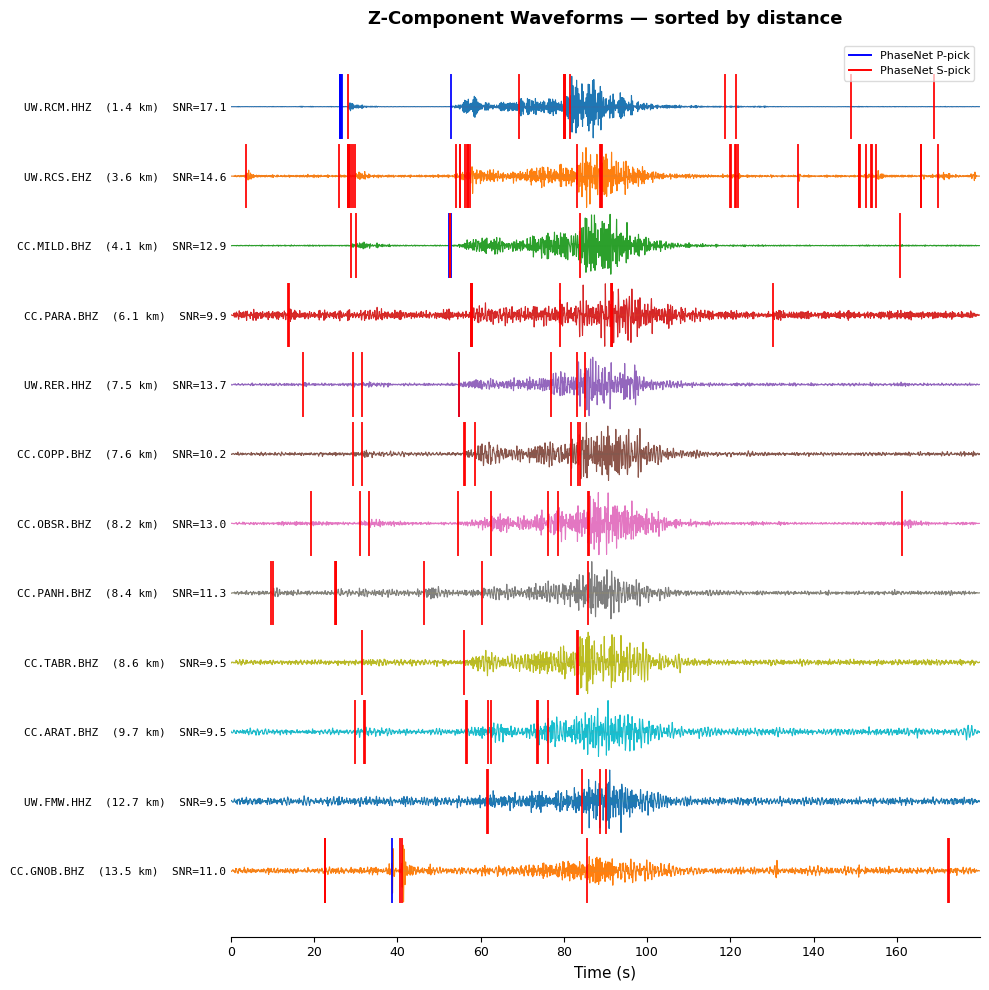

In [17]:
"""
Plot processed Z-component waveforms in a single figure with PhaseNet picks.
- Figure size (15, 10)
- SNR filter: max(envelope) / mean(envelope) >= SNR_THRESHOLD
- One axis, traces stacked vertically offset by row index
- Each trace a different color
- Amplitude normalised by per-trace maximum
- PhaseNet P (blue) and S (red) picks plotted as vertical lines per trace
- Y-tick labels: network.station.channel  (distance km)  SNR=XX.X
- Nearest station at top, farthest at bottom

Requires: pip install obspy matplotlib scipy seisbench torch
"""

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.signal import hilbert
from obspy import Stream
import seisbench.models as sbm

# ─────────────────────────────────────────────
FIGURE_TITLE  = "Z-Component Waveforms — sorted by distance"
OUTPUT_FILE   = "z_waveforms.png"   # None → interactive only
DPI           = 150
TRACE_SCALE   = 0.45    # half-height of each normalised waveform (0–1)
SNR_THRESHOLD = 8.0     # min max(envelope)/mean(envelope) to keep a trace

# ── PhaseNet pick thresholds ──
PN_P_THRESHOLD = 0.1    # minimum P-pick probability to plot
PN_S_THRESHOLD = 0.1    # minimum S-pick probability to plot

CUSTOM_COLORS = [
    "#DC143C", "#1E90FF", "#228B22", "#FF8C00", "#9370DB",
    "#008080", "#FF69B4", "#FFD700", "#6A5ACD", "#FF6347",
    "#32CD32", "#00BFFF", "#8B4513", "#BA55D3", "#00FF7F",
    "#B22222", "#4682B4", "#B8860B", "#40E0D0", "#6B8E23",
    "#FF4500", "#5F9EA0", "#9400D3",
]
# ─────────────────────────────────────────────


def compute_snr(trace) -> float:
    """SNR = max(envelope) / mean(envelope) using the Hilbert envelope."""
    envelope = np.abs(hilbert(trace.data))
    mean_env = np.mean(envelope)
    if mean_env == 0:
        return 0.0
    return float(np.max(envelope) / mean_env)


def deduplicate_by_station(stream):
    """Keep only the highest-SNR trace per network.station pair."""
    for tr in stream:
        if not hasattr(tr.stats, "snr"):
            tr.stats.snr = compute_snr(tr)

    best = {}
    for tr in stream:
        key = (tr.stats.network, tr.stats.station)
        if key not in best or tr.stats.snr > best[key].stats.snr:
            best[key] = tr

    deduped = Stream(list(best.values()))
    removed = len(stream) - len(deduped)
    if removed:
        print(f"\nDeduplicated: removed {removed} lower-SNR duplicate(s) "
              f"({len(deduped)} trace(s) remaining).")
    return deduped


def filter_by_snr(stream, threshold: float = SNR_THRESHOLD):
    """Return a Stream containing only traces with SNR >= threshold."""
    good = Stream()
    rejected = []
    for tr in stream:
        snr = compute_snr(tr)
        tr.stats.snr = snr
        if snr >= threshold:
            good += tr
        else:
            rejected.append((tr.id, snr))

    print(f"\nSNR filter (threshold={threshold}):")
    print(f"  Kept    : {len(good)} trace(s)")
    print(f"  Rejected: {len(rejected)} trace(s)")
    for tid, snr in rejected:
        print(f"    {tid}  SNR={snr:.2f}")
    return good


def run_phasenet(stream):
    """
    Run PhaseNet (STEAD weights) on each trace and collect P/S pick times
    in seconds relative to each trace's start time.

    PhaseNet annotate() returns a stream of probability traces with channel
    suffixes _P, _S, and _N (noise). We find peaks above threshold in the
    P and S probability traces.

    Returns
    -------
    dict mapping tr.id → {"P": [t_sec, ...], "S": [t_sec, ...]}
    """
    print("\nLoading PhaseNet (stead weights) …")
    pn_model = sbm.PhaseNet.from_pretrained("stead")
    pn_model.eval()

    picks_dict = {}

    for tr in stream:
        st_single = Stream([tr.copy()])
        try:
            annotations = pn_model.annotate(st_single)
        except Exception as e:
            print(f"  PhaseNet failed for {tr.id}: {e}")
            picks_dict[tr.id] = {"P": [], "S": []}
            continue

        p_times, s_times = [], []

        for ann_tr in annotations:
            label      = ann_tr.stats.channel        # e.g. "..PhaseNet_P", "_S", "_N"
            prob       = ann_tr.data
            fs_ann     = ann_tr.stats.sampling_rate
            offset_sec = ann_tr.stats.starttime - tr.stats.starttime

            if label.endswith("_P"):
                threshold = PN_P_THRESHOLD
                target    = p_times
            elif label.endswith("_S"):
                threshold = PN_S_THRESHOLD
                target    = s_times
            else:
                continue   # noise channel — skip

            peaks = np.where(prob >= threshold)[0]
            if len(peaks):
                groups = np.split(peaks, np.where(np.diff(peaks) > 1)[0] + 1)
                for grp in groups:
                    best_idx = grp[np.argmax(prob[grp])]
                    target.append(offset_sec + best_idx / fs_ann)

        picks_dict[tr.id] = {"P": p_times, "S": s_times}
        print(f"  {tr.id}: {len(p_times)} P-pick(s), {len(s_times)} S-pick(s)")

    return picks_dict


def plot_z_stream(stream, title: str = FIGURE_TITLE, output_file: str = OUTPUT_FILE):
    """
    Plot all traces in `stream` on a single axes, stacked nearest → farthest.
    Pipeline: deduplicate → SNR filter → EQT picks → plot.
    Stream must already be sorted by distance_km.
    """
    # ── Deduplicate & SNR filter ──
    stream = deduplicate_by_station(stream)
    stream = filter_by_snr(stream)

    if not stream:
        print("No traces passed the SNR filter — nothing to plot.")
        return

    # ── Run PhaseNet on the clean stream ──
    eqt_picks = run_phasenet(stream)

    n = len(stream)
    colors  = [CUSTOM_COLORS[i % len(CUSTOM_COLORS)] for i in range(n)]
    offsets = list(range(n - 1, -1, -1))   # nearest at top

    fig, ax = plt.subplots(figsize=(10, 10))

    ytick_positions = []
    ytick_labels    = []

    for tr, color, offset in zip(stream, colors, offsets):
        times = tr.times()
        peak  = np.max(np.abs(tr.data))
        data  = tr.data / (peak + 1e-10) * TRACE_SCALE

        # Waveform
        ax.plot(times, data + offset, linewidth=0.8)
        ax.axhline(offset, color=color, linewidth=0.3, linestyle="--", alpha=0.35)

        # ── EQT picks ──
        picks = eqt_picks.get(tr.id, {"P": [], "S": []})

        for t_p in picks["P"]:
            ax.plot([t_p, t_p],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="blue", linewidth=1.4, linestyle="-", alpha=0.9, zorder=3)

        for t_s in picks["S"]:
            ax.plot([t_s, t_s],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="red", linewidth=1.4, linestyle="-", alpha=0.9, zorder=3)

        # Y-tick label
        st       = tr.stats
        dist     = getattr(st, "distance_km", None)
        snr      = getattr(st, "snr", None)
        dist_str = f"{dist:.1f} km" if dist is not None else "? km"
        snr_str  = f"  SNR={snr:.1f}" if snr is not None else ""
        label    = f"{st.network}.{st.station}.{st.channel}  ({dist_str}){snr_str}"

        ytick_positions.append(offset)
        ytick_labels.append(label)

    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=8, fontfamily="monospace")
    ax.yaxis.set_tick_params(length=0)

    ax.set_ylim(-0.5 - TRACE_SCALE, n - 0.5 + TRACE_SCALE)
    ax.set_xlim(stream[0].times()[0], stream[0].times()[-1])
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)

    # ── Legend ──
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="blue", linewidth=1.4, linestyle="-", label="PhaseNet P-pick"),
        Line2D([0], [0], color="red",  linewidth=1.4, linestyle="-", label="PhaseNet S-pick"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.7)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=DPI, bbox_inches="tight")
        print(f"\nPlot saved → {output_file}")

    plt.show()
    return fig


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
if __name__ == "__main__":
    stream    = get_z_stream()
    processed = preprocess(stream)
    sorted_st = sort_by_distance(processed)

    plot_z_stream(sorted_st)

Preprocessing 36 trace(s) …

  CC.ARAT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CARB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.COPP..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CRBN..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GNOB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GTWY..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAUT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAVK..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.MILD..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampl

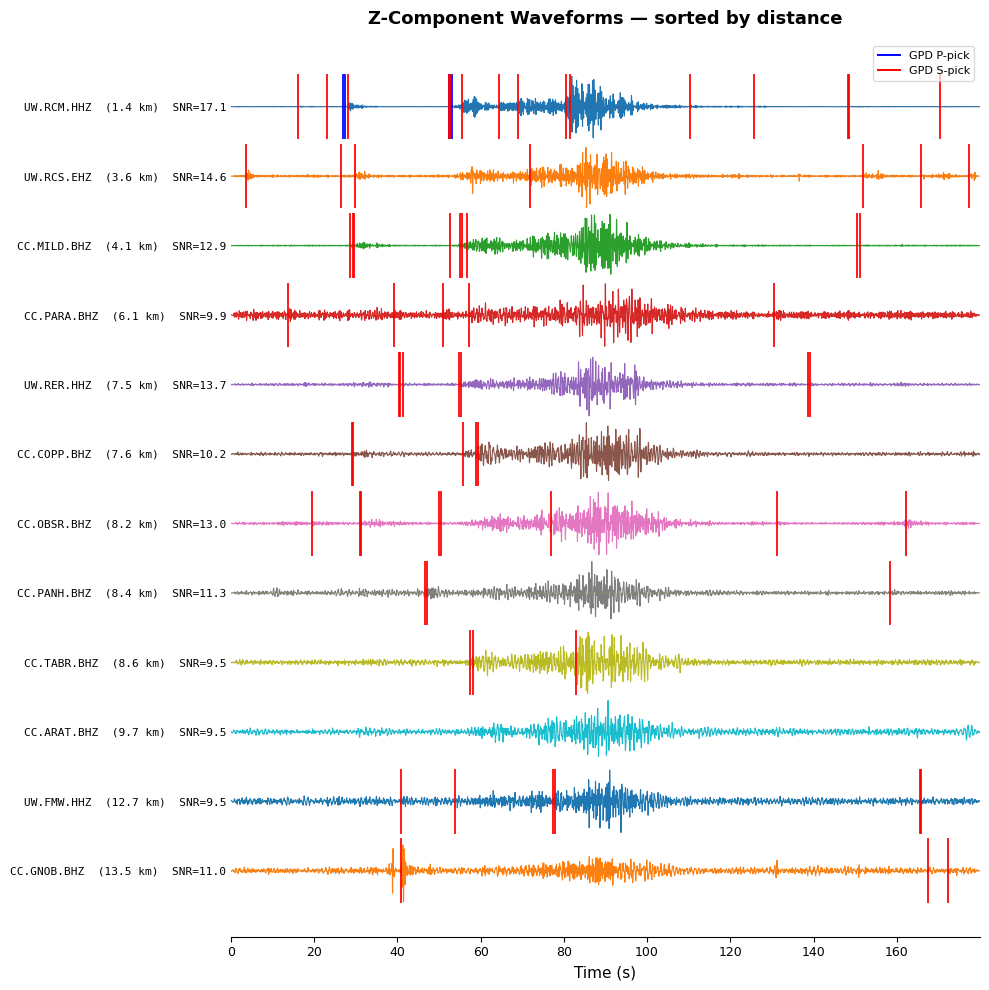

In [20]:
"""
Plot processed Z-component waveforms in a single figure with GPD picks.
- Figure size (15, 10)
- SNR filter: max(envelope) / mean(envelope) >= SNR_THRESHOLD
- One axis, traces stacked vertically offset by row index
- Each trace a different color
- Amplitude normalised by per-trace maximum
- GPD P (blue) and S (red) picks plotted as vertical lines per trace
- Y-tick labels: network.station.channel  (distance km)  SNR=XX.X
- Nearest station at top, farthest at bottom

Requires: pip install obspy matplotlib scipy seisbench torch
"""

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.signal import hilbert
from obspy import Stream
import seisbench.models as sbm

# ─────────────────────────────────────────────
FIGURE_TITLE  = "Z-Component Waveforms — sorted by distance"
OUTPUT_FILE   = "z_waveforms.png"   # None → interactive only
DPI           = 150
TRACE_SCALE   = 0.45    # half-height of each normalised waveform (0–1)
SNR_THRESHOLD = 8.0     # min max(envelope)/mean(envelope) to keep a trace

# ── GPD pick thresholds ──
GPD_P_THRESHOLD = 0.1   # minimum P-pick probability to plot
GPD_S_THRESHOLD = 0.3   # minimum S-pick probability to plot

CUSTOM_COLORS = [
    "#DC143C", "#1E90FF", "#228B22", "#FF8C00", "#9370DB",
    "#008080", "#FF69B4", "#FFD700", "#6A5ACD", "#FF6347",
    "#32CD32", "#00BFFF", "#8B4513", "#BA55D3", "#00FF7F",
    "#B22222", "#4682B4", "#B8860B", "#40E0D0", "#6B8E23",
    "#FF4500", "#5F9EA0", "#9400D3",
]
# ─────────────────────────────────────────────


def compute_snr(trace) -> float:
    """SNR = max(envelope) / mean(envelope) using the Hilbert envelope."""
    envelope = np.abs(hilbert(trace.data))
    mean_env = np.mean(envelope)
    if mean_env == 0:
        return 0.0
    return float(np.max(envelope) / mean_env)


def deduplicate_by_station(stream):
    """Keep only the highest-SNR trace per network.station pair."""
    for tr in stream:
        if not hasattr(tr.stats, "snr"):
            tr.stats.snr = compute_snr(tr)

    best = {}
    for tr in stream:
        key = (tr.stats.network, tr.stats.station)
        if key not in best or tr.stats.snr > best[key].stats.snr:
            best[key] = tr

    deduped = Stream(list(best.values()))
    removed = len(stream) - len(deduped)
    if removed:
        print(f"\nDeduplicated: removed {removed} lower-SNR duplicate(s) "
              f"({len(deduped)} trace(s) remaining).")
    return deduped


def filter_by_snr(stream, threshold: float = SNR_THRESHOLD):
    """Return a Stream containing only traces with SNR >= threshold."""
    good = Stream()
    rejected = []
    for tr in stream:
        snr = compute_snr(tr)
        tr.stats.snr = snr
        if snr >= threshold:
            good += tr
        else:
            rejected.append((tr.id, snr))

    print(f"\nSNR filter (threshold={threshold}):")
    print(f"  Kept    : {len(good)} trace(s)")
    print(f"  Rejected: {len(rejected)} trace(s)")
    for tid, snr in rejected:
        print(f"    {tid}  SNR={snr:.2f}")
    return good


def run_gpd(stream):
    """
    Run GPD (Generalized Phase Detection, STEAD weights) on each trace
    and collect P/S pick times in seconds relative to each trace's start.

    GPD is a window-based classifier. SeisBench's annotate() slides a window
    across the trace and returns per-sample P, S, and noise probability traces
    with channel suffixes _P, _S, _N.

    Returns
    -------
    dict mapping tr.id → {"P": [t_sec, ...], "S": [t_sec, ...]}
    """
    print("\nLoading GPD (stead weights) …")
    gpd_model = sbm.GPD.from_pretrained("stead")
    gpd_model.eval()

    picks_dict = {}

    for tr in stream:
        st_single = Stream([tr.copy()])
        try:
            annotations = gpd_model.annotate(st_single)
        except Exception as e:
            print(f"  GPD failed for {tr.id}: {e}")
            picks_dict[tr.id] = {"P": [], "S": []}
            continue

        p_times, s_times = [], []

        for ann_tr in annotations:
            label      = ann_tr.stats.channel   # e.g. "...GPD_P", "_S", "_N"
            prob       = ann_tr.data
            fs_ann     = ann_tr.stats.sampling_rate
            offset_sec = ann_tr.stats.starttime - tr.stats.starttime

            if label.endswith("_P"):
                threshold = GPD_P_THRESHOLD
                target    = p_times
            elif label.endswith("_S"):
                threshold = GPD_S_THRESHOLD
                target    = s_times
            else:
                continue   # noise channel — skip

            peaks = np.where(prob >= threshold)[0]
            if len(peaks):
                # Group consecutive high-prob samples; keep peak of each group
                groups = np.split(peaks, np.where(np.diff(peaks) > 1)[0] + 1)
                for grp in groups:
                    best_idx = grp[np.argmax(prob[grp])]
                    target.append(offset_sec + best_idx / fs_ann)

        picks_dict[tr.id] = {"P": p_times, "S": s_times}
        print(f"  {tr.id}: {len(p_times)} P-pick(s), {len(s_times)} S-pick(s)")

    return picks_dict


def plot_z_stream(stream, title: str = FIGURE_TITLE, output_file: str = OUTPUT_FILE):
    """
    Plot all traces in `stream` on a single axes, stacked nearest → farthest.
    Pipeline: deduplicate → SNR filter → GPD picks → plot.
    Stream must already be sorted by distance_km.
    """
    # ── Deduplicate & SNR filter ──
    stream = deduplicate_by_station(stream)
    stream = filter_by_snr(stream)

    if not stream:
        print("No traces passed the SNR filter — nothing to plot.")
        return

    # ── Run GPD on the clean stream ──
    gpd_picks = run_gpd(stream)

    n = len(stream)
    colors  = [CUSTOM_COLORS[i % len(CUSTOM_COLORS)] for i in range(n)]
    offsets = list(range(n - 1, -1, -1))   # nearest at top

    fig, ax = plt.subplots(figsize=(10, 10))

    ytick_positions = []
    ytick_labels    = []

    for tr, color, offset in zip(stream, colors, offsets):
        times = tr.times()
        peak  = np.max(np.abs(tr.data))
        data  = tr.data / (peak + 1e-10) * TRACE_SCALE

        # Waveform
        ax.plot(times, data + offset, linewidth=0.8)
        ax.axhline(offset, color=color, linewidth=0.3, linestyle="--", alpha=0.35)

        # ── GPD picks ──
        picks = gpd_picks.get(tr.id, {"P": [], "S": []})

        for t_p in picks["P"]:
            ax.plot([t_p, t_p],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="blue", linewidth=1.4, linestyle="-", alpha=0.9, zorder=3)

        for t_s in picks["S"]:
            ax.plot([t_s, t_s],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="red", linewidth=1.4, linestyle="-", alpha=0.9, zorder=3)

        # Y-tick label
        st       = tr.stats
        dist     = getattr(st, "distance_km", None)
        snr      = getattr(st, "snr", None)
        dist_str = f"{dist:.1f} km" if dist is not None else "? km"
        snr_str  = f"  SNR={snr:.1f}" if snr is not None else ""
        label    = f"{st.network}.{st.station}.{st.channel}  ({dist_str}){snr_str}"

        ytick_positions.append(offset)
        ytick_labels.append(label)

    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=8, fontfamily="monospace")
    ax.yaxis.set_tick_params(length=0)

    ax.set_ylim(-0.5 - TRACE_SCALE, n - 0.5 + TRACE_SCALE)
    ax.set_xlim(stream[0].times()[0], stream[0].times()[-1])
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)

    # ── Legend ──
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="blue", linewidth=1.4, linestyle="-", label="GPD P-pick"),
        Line2D([0], [0], color="red",  linewidth=1.4, linestyle="-", label="GPD S-pick"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.7)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=DPI, bbox_inches="tight")
        print(f"\nPlot saved → {output_file}")

    plt.show()
    return fig


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
if __name__ == "__main__":
    stream    = get_z_stream()
    processed = preprocess(stream)
    sorted_st = sort_by_distance(processed)

    plot_z_stream(sorted_st)

## Plotting the results of a kurtosis based picker

In [31]:
"""
Test multiple pickers on different waveform representations (raw, filtered, spectrograms).
Prepare for picker retraining and location finding.
"""
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import ast
from pathlib import Path
from typing import Optional, List, Tuple, Dict, Any

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from scipy.signal import spectrogram
from tqdm import tqdm


from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees


# ----------------------------
# Utilities
# ----------------------------
def bandpass(x: np.ndarray, fs: float, fmin: float, fmax: float, order: int = 3) -> np.ndarray:
    """Zero-phase Butterworth bandpass."""
    x = np.asarray(x, dtype=float)
    nyq = 0.5 * fs
    fmin = max(1e-6, float(fmin))
    fmax = min(float(fmax), nyq - 1e-6)
    if fmin >= fmax:
        return x.copy()
    b, a = butter(order, [fmin / nyq, fmax / nyq], btype="band")
    return filtfilt(b, a, x)


def moving_average(x: np.ndarray, win: int) -> np.ndarray:
    """Centered moving average with reflect padding."""
    x = np.asarray(x, dtype=float)
    if win <= 1:
        return x.copy()
    w = np.ones(win, dtype=float) / float(win)
    pad = win // 2
    xp = np.pad(x, (pad, pad), mode="reflect")
    y = np.convolve(xp, w, mode="valid")
    return y[: x.size]


# ----------------------------
# Rolling kurtosis (central moments) = Eq (8)-(10) style
# ----------------------------
def rolling_kurtosis_trailing(x: np.ndarray, win: int) -> np.ndarray:
    """
    Trailing-window kurtosis (NOT excess):
      K = mu4 / mu2^2
    computed on window x[k-win+1 : k+1].

    Output aligned to original indices: first win-1 values are NaN.
    O(n) via cumulative sums of powers.
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    out = np.full(n, np.nan, dtype=float)
    if win < 4 or win > n:
        return out

    x1 = x
    x2 = x1 * x1
    x3 = x2 * x1
    x4 = x2 * x2

    c1 = np.cumsum(x1)
    c2 = np.cumsum(x2)
    c3 = np.cumsum(x3)
    c4 = np.cumsum(x4)

    def wsum(c):
        return c[win - 1:] - np.concatenate(([0.0], c[:-win]))

    S1 = wsum(c1)
    S2 = wsum(c2)
    S3 = wsum(c3)
    S4 = wsum(c4)

    N = float(win)
    m1 = S1 / N
    ex2 = S2 / N
    ex3 = S3 / N
    ex4 = S4 / N

    mu2 = ex2 - m1**2
    # E[(x-m)^4] = E[x^4] -4mE[x^3] +6m^2E[x^2] -4m^3E[x] + m^4
    mu4 = ex4 - 4*m1*ex3 + 6*(m1**2)*ex2 - 4*(m1**3)*m1 + (m1**4)

    eps = 1e-12
    K = mu4 / np.maximum(mu2, eps) ** 2
    out[win - 1:] = K
    return out


# ----------------------------
# APP transformations: F1 -> F2 -> F3 -> F4
# ----------------------------
def f1_to_f2(F1: np.ndarray) -> np.ndarray:
    """
    Eq (11) logic from your screenshot:
      F2(1)=F1(1)
      F2(k+1)=F2(k)+delta(k)*dF1(k)
      delta=1 if dF1>=0 else 0
    """
    F1 = np.asarray(F1, dtype=float)
    F2 = np.full_like(F1, np.nan)
    finite = np.isfinite(F1)
    if not np.any(finite):
        return F2

    idx = np.where(finite)[0]
    start = idx[0]

    F2[start] = F1[start]
    d = np.diff(F1[start:])
    d = np.where(np.isfinite(d), d, 0.0)
    inc = np.maximum(d, 0.0)
    F2[start + 1 : start + 1 + inc.size] = F2[start] + np.cumsum(inc)
    return F2


def f2_to_f3(F2: np.ndarray) -> np.ndarray:
    """
    Detrend endpoints:
      F3(k) = F2(k) - [a*(k-1)+b]
      a=(F2(n)-F2(1))/(n-1), b=F2(1)
    (Implemented over the finite span.)
    """
    F2 = np.asarray(F2, dtype=float)
    F3 = F2.copy()
    idx = np.where(np.isfinite(F2))[0]
    if idx.size < 2:
        return F3

    i0, i1 = idx[0], idx[-1]
    b = F2[i0]
    a = (F2[i1] - F2[i0]) / float(i1 - i0)

    k = np.arange(i0, i1 + 1, dtype=float)
    line = a * (k - i0) + b
    F3[i0 : i1 + 1] = F2[i0 : i1 + 1] - line
    return F3


def f3_to_f4(F3: np.ndarray, min_peak_distance: int = 1) -> np.ndarray:
    """
    Implements the paper's idea:
      T(k) = F3(k) - M_{i+1} for k in (s_i, s_{i+1}]
      F4(k) = T(k) if T(k)<0 else 0
    where M_i are local maxima of F3 at indices s_i.
    """
    F3 = np.asarray(F3, dtype=float)
    F4 = np.full_like(F3, np.nan)

    finite = np.isfinite(F3)
    if np.sum(finite) < 10:
        return F4

    x = F3.copy()
    x[~finite] = np.nanmin(x[finite])

    peaks, _ = find_peaks(x, distance=max(1, int(min_peak_distance)))
    if peaks.size == 0:
        # If no peaks, just clamp positives to 0 (still yields negative dips if any)
        tmp = np.minimum(F3, 0.0)
        F4[np.isfinite(tmp)] = tmp[np.isfinite(tmp)]
        return F4

    M = x[peaks]  # peak heights

    # for each k, find the first peak index >= k (the "next maximum")
    next_peak_idx = np.searchsorted(peaks, np.arange(len(x)), side="left")
    next_peak_idx = np.clip(next_peak_idx, 0, peaks.size - 1)
    next_max = M[next_peak_idx]

    T = F3 - next_max
    F4 = np.where(np.isfinite(T), np.minimum(T, 0.0), np.nan)  # keep negatives, else 0
    return F4


# ----------------------------
# Picking on F4 + long-to-short refinement
# ----------------------------

def minima_indices(
    F4: np.ndarray,
    fs: float,
    min_sep_s: float = 0.5,
    prominence: Optional[float] = None
) -> np.ndarray:
    """
    Minima in F4 are picked by finding peaks in -F4 (because minima are negative dips).
    """
    y = np.asarray(F4, dtype=float)
    if not np.any(np.isfinite(y)):
        return np.array([], dtype=int)

    z = -y
    z[~np.isfinite(z)] = 0.0
    dist = max(1, int(round(min_sep_s * fs)))

    kwargs = {"distance": dist}
    if prominence is not None:
        kwargs["prominence"] = float(prominence)

    pk, _ = find_peaks(z, **kwargs)
    pk = pk[y[pk] < 0]  # ensure it's a negative dip in F4
    return np.sort(pk)


def long_to_short_refinement(
    F3_avg: np.ndarray,
    fs: float,
    smooth_windows_s: List[float],
    min_sep_s: float = 0.5,
    search_radius_s: Optional[float] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    - Smooth F3_avg at multiple scales (largest -> smallest).
    - Compute F4 at each scale.
    - Pick minima on the smoothest F4.
    - Snap those picks to nearest minima at the next (less-smoothed) scale, repeat.
    Returns: refined_pick_indices, F4_at_least_smoothed_scale
    """
    if len(smooth_windows_s) == 0:
        smooth_windows_s = [0.0]
    smooth_windows_s = sorted(smooth_windows_s, reverse=True)

    mins_levels = []
    F4_levels = []

    for sw in smooth_windows_s:
        win = max(1, int(round(sw * fs)))
        F3s = moving_average(F3_avg, win)
        F4s = f3_to_f4(F3s, min_peak_distance=max(1, int(0.1 * fs)))
        mins = minima_indices(F4s, fs, min_sep_s=min_sep_s)
        mins_levels.append(mins)
        F4_levels.append(F4s)

    picks = mins_levels[0].copy()
    if picks.size == 0:
        return picks, F4_levels[-1]

    if search_radius_s is None:
        # half of coarsest smoothing window, but at least 0.5s
        search_radius_s = max(0.5, 0.5 * smooth_windows_s[0])
    R = int(round(search_radius_s * fs))

    for mins in mins_levels[1:]:
        if mins.size == 0:
            continue
        new_picks = []
        for p in picks:
            lo, hi = p - R, p + R
            c = mins[(mins >= lo) & (mins <= hi)]
            if c.size == 0:
                new_picks.append(p)
            else:
                new_picks.append(int(c[np.argmin(np.abs(c - p))]))
        picks = np.array(new_picks, dtype=int)

    picks = np.unique(picks)
    return picks, F4_levels[-1]



def app_vertical_picker_with_debug(
    x: np.ndarray,
    fs: float,
    frequency_bands: List[Tuple[float, float]],
    ws_s: List[float],
    smooth_windows_s: List[float],  # kept for compatibility; not used for gating anymore
    *,
    debug_band: Optional[Tuple[float, float]] = None,
    debug_ws_s: Optional[float] = None,
    max_picks: int = 2,
    choose: str = "shape",              # "shape" (recommended), "earliest", "strongest"
    min_sep_s: float = 0.6,
    filter_order: int = 3,
    detrend_mean: bool = True,
    ignore_first_s: float = 5.0,        # helps kill edge artifacts
    lookahead_s: float = 1.0,           # Δ lookahead window for "peak follows dip"
    depth_weight: float = 0.2,          # small weight; Δ is main driver
    return_debug: bool = True,
):
    x = np.asarray(x, dtype=float)
    if detrend_mean:
        x = x - np.nanmean(x)

    if debug_band is None:
        debug_band = frequency_bands[0]
    if debug_ws_s is None:
        debug_ws_s = ws_s[0]

    dbg = {}

    # Build all F3s for averaging
    F3_list = []
    F3_labels = []   # <-- NEW (optional)
    found_debug_pair = False

    for fmin, fmax in frequency_bands:
        xf = bandpass(x, fs, fmin, fmax, order=filter_order)
        xf = xf - np.mean(xf)

        for ws in ws_s:
            win = max(4, int(round(ws * fs)))
            F1 = rolling_kurtosis_trailing(xf, win)
            F2 = f1_to_f2(F1)
            F3 = f2_to_f3(F2)

            F3_list.append(F3)
            F3_labels.append(f"{fmin:g}-{fmax:g} Hz | WS={ws:g} s")  # <-- NEW

            if (fmin, fmax) == tuple(debug_band) and float(ws) == float(debug_ws_s):
                dbg["filtered_example"] = xf
                dbg["F1_example"] = F1
                dbg["F2_example"] = F2
                dbg["F3_example"] = F3
                dbg["debug_band"] = (fmin, fmax)
                dbg["debug_ws_s"] = ws
                found_debug_pair = True

    # <-- NEW: store all F3s ALWAYS (not only in fallback)
    if return_debug:
        dbg["F3_all"] = F3_list
        dbg["F3_labels"] = F3_labels

    # F3 averaged across all band×window settings
    F3_stack = np.vstack([np.nan_to_num(f, nan=np.nan) for f in F3_list])
    F3_avg = np.nanmean(F3_stack, axis=0)

    # If debug pair wasn't matched exactly, compute it once explicitly
    if not found_debug_pair:
        fmin, fmax = debug_band
        xf = bandpass(x, fs, fmin, fmax, order=filter_order)
        xf = xf - np.mean(xf)
        win = max(4, int(round(float(debug_ws_s) * fs)))
        F1 = rolling_kurtosis_trailing(xf, win)
        F2 = f1_to_f2(F1)
        F3 = f2_to_f3(F2)
        dbg["filtered_example"] = xf
        dbg["F1_example"] = F1
        dbg["F2_example"] = F2
        dbg["F3_example"] = F3
        dbg["debug_band"] = (fmin, fmax)
        dbg["debug_ws_s"] = float(debug_ws_s)

    # Compute final F4 from averaged F3
    F4_final = f3_to_f4(F3_avg, min_peak_distance=max(1, int(0.1 * fs)))

    # Candidate minima directly from final F4
    candidates = minima_indices(F4_final, fs, min_sep_s=min_sep_s)

    # Ignore early edge artifacts
    if ignore_first_s is not None and ignore_first_s > 0:
        candidates = candidates[(candidates / float(fs)) >= float(ignore_first_s)]

    # No candidates
    if candidates.size == 0:
        picks_idx = np.array([], dtype=int)
        picks_t = np.array([], dtype=float)
        if return_debug:
            dbg.update({
                "raw": x,
                "F3_avg": F3_avg,
                "F4_final": F4_final,
                "candidates": candidates,
                "ranked": np.array([], dtype=int),
                "scores": np.array([]),
                "deltas": np.array([]),
                "depths": np.array([]),
                "picks_idx": picks_idx,
                "picks_t": picks_t,
            })
            return picks_idx, picks_t, dbg
        return picks_idx, picks_t

    # earliest
    if choose.lower() == "earliest":
        picks_idx = np.sort(candidates)[:max_picks]
        picks_t = picks_idx / float(fs)
        if return_debug:
            dbg.update({
                "raw": x,
                "F3_avg": F3_avg,
                "F4_final": F4_final,
                "candidates": candidates,
                "ranked": np.sort(candidates),
                "scores": np.array([]),
                "deltas": np.array([]),
                "depths": np.array([]),
                "picks_idx": picks_idx,
                "picks_t": picks_t,
            })
            return picks_idx, picks_t, dbg
        return picks_idx, picks_t

    # strongest (by F4 depth only)
    if choose.lower() == "strongest":
        strengths = -F4_final[candidates]
        order = np.argsort(strengths)[::-1]
        ranked = candidates[order]
        picks_idx = np.sort(ranked[:max_picks])
        picks_t = picks_idx / float(fs)
        if return_debug:
            dbg.update({
                "raw": x,
                "F3_avg": F3_avg,
                "F4_final": F4_final,
                "candidates": candidates,
                "ranked": ranked,
                "scores": strengths[order],
                "deltas": np.array([]),
                "depths": np.maximum(0.0, strengths[order]),
                "picks_idx": picks_idx,
                "picks_t": picks_t,
            })
            return picks_idx, picks_t, dbg
        return picks_idx, picks_t

    # shape (recommended): Δ lookahead on F3_avg (+ small depth term)
    ranked, scores, deltas, depths = rank_minima_by_following_rise(
        candidates,
        F3_avg,
        fs,
        lookahead_s=lookahead_s,
        combine_with_depth=True,
        F4=F4_final,
        depth_weight=depth_weight,
    )

    if ranked.size == 0:
        picks_idx = np.array([], dtype=int)
        picks_t = np.array([], dtype=float)
    else:
        picks_idx = np.sort(ranked[:max_picks])
        picks_t = picks_idx / float(fs)

    if return_debug:
        dbg.update({
            "raw": x,
            "F3_avg": F3_avg,
            "F4_final": F4_final,
            "candidates": candidates,
            "ranked": ranked,
            "scores": scores,
            "deltas": deltas,
            "depths": depths,
            "ignore_first_s": ignore_first_s,
            "lookahead_s": lookahead_s,
            "depth_weight": depth_weight,
            "choose": choose,
            "picks_idx": picks_idx,
            "picks_t": picks_t,
        })
        return picks_idx, picks_t, dbg

    return picks_idx, picks_t



def rank_minima_by_following_rise(
    minima_idx: np.ndarray,
    F3: np.ndarray,
    fs: float,
    lookahead_s: float = 5.0,
    combine_with_depth: bool = True,
    F4: Optional[np.ndarray] = None,
    depth_weight: float = 0.2,
):
    """
    For each candidate minimum p, compute:
        delta = max(F3[p:p+W]) - F3[p]
    Optionally combine with dip depth in F4:
        score = delta + depth_weight * (-F4[p])

    Returns minima sorted by descending score and arrays of (score, delta, depth).
    """
    minima_idx = np.asarray(minima_idx, dtype=int)
    if minima_idx.size == 0:
        return np.array([], dtype=int), np.array([]), np.array([]), np.array([])

    W = max(1, int(round(lookahead_s * fs)))
    n = len(F3)

    valid_p = []
    scores = []
    deltas = []
    depths = []

    for p in minima_idx:
        if p < 0 or p >= n:
            continue

        hi = min(n, p + W)
        if hi <= p + 1:
            continue

        base = F3[p]
        seg = F3[p:hi]
        if not np.isfinite(base) or not np.any(np.isfinite(seg)):
            continue

        delta = float(np.nanmax(seg) - base)

        depth = 0.0
        if F4 is not None and p < len(F4) and np.isfinite(F4[p]):
            depth = max(0.0, -float(F4[p]))

        score = delta
        if combine_with_depth:
            score = score + float(depth_weight) * depth

        valid_p.append(int(p))
        scores.append(float(score))
        deltas.append(float(delta))
        depths.append(float(depth))

    if len(valid_p) == 0:
        return np.array([], dtype=int), np.array([]), np.array([]), np.array([])

    valid_p = np.asarray(valid_p, dtype=int)
    scores = np.asarray(scores, dtype=float)
    deltas = np.asarray(deltas, dtype=float)
    depths = np.asarray(depths, dtype=float)

    order = np.argsort(scores)[::-1]
    return valid_p[order], scores[order], deltas[order], depths[order]

Preprocessing 36 trace(s) …

  CC.ARAT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CARB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.COPP..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.CRBN..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GNOB..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.GTWY..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAUT..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.KAVK..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampled to 50.0 Hz, detrended, tapered, bandpass 1.0–5.0 Hz
  CC.MILD..BHZ  (fs=50.0 Hz, 9001 samples)
       → resampl

/tmp/ipykernel_100328/2337934065.py:342: RuntimeWarning: Mean of empty slice
  F3_avg = np.nanmean(F3_stack, axis=0)


  CC.PANH..BHZ: 2 kurtosis pick(s) → 29.94s, 30.60s
  CC.TABR..BHZ: 2 kurtosis pick(s) → 50.72s, 148.72s
  CC.ARAT..BHZ: 2 kurtosis pick(s) → 20.52s, 140.32s
  UW.FMW..HHZ: 2 kurtosis pick(s) → 53.46s, 165.86s
  CC.GNOB..BHZ: 2 kurtosis pick(s) → 37.74s, 40.90s

Plot saved → z_waveforms.png


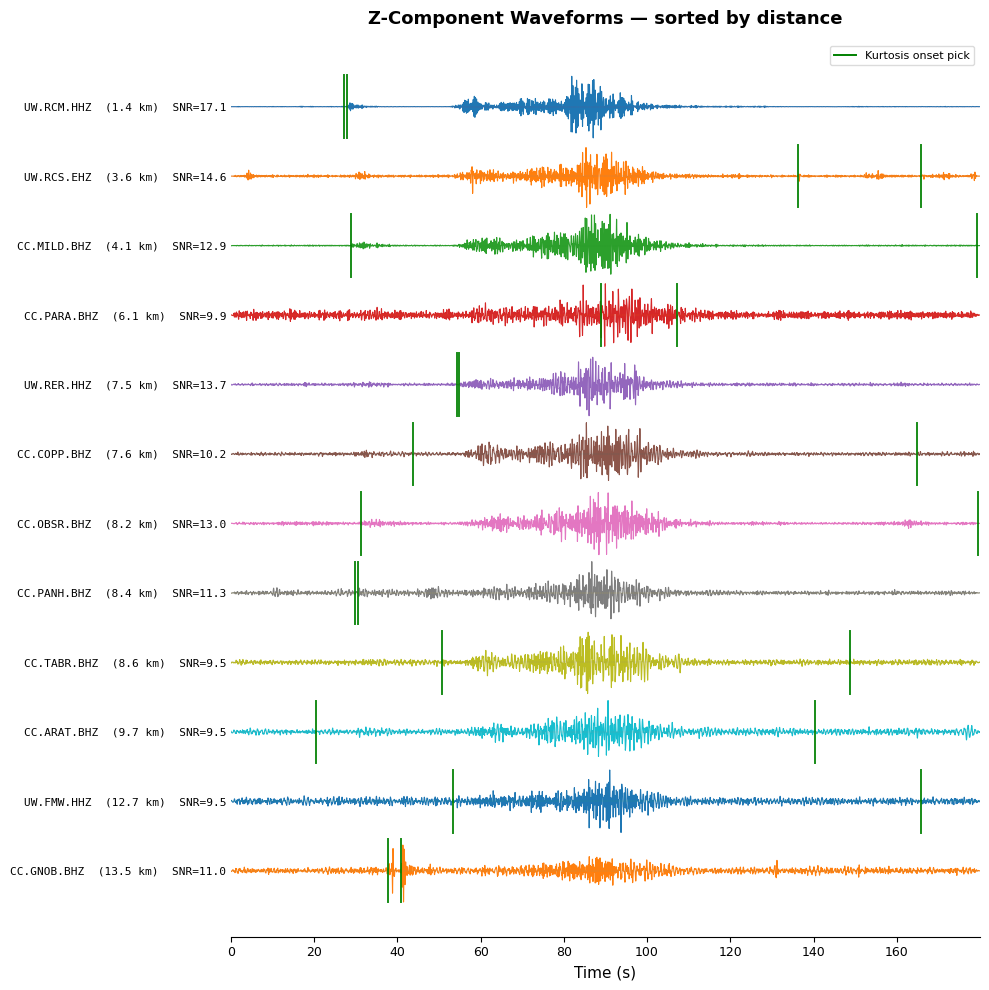

In [33]:
"""
Plot processed Z-component waveforms in a single figure with kurtosis-based picks.
- Figure size (15, 10)
- SNR filter: max(envelope) / mean(envelope) >= SNR_THRESHOLD
- One axis, traces stacked vertically offset by row index
- Each trace a different color
- Amplitude normalised by per-trace maximum
- Kurtosis onset picks plotted as green vertical lines per trace
- Y-tick labels: network.station.channel  (distance km)  SNR=XX.X
- Nearest station at top, farthest at bottom

Requires: pip install obspy matplotlib scipy
"""

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.signal import hilbert
from obspy import Stream
import seisbench.models as sbm

# ─────────────────────────────────────────────
FIGURE_TITLE  = "Z-Component Waveforms — sorted by distance"
OUTPUT_FILE   = "z_waveforms.png"   # None → interactive only
DPI           = 150
TRACE_SCALE   = 0.45    # half-height of each normalised waveform (0–1)
SNR_THRESHOLD = 8.0     # min max(envelope)/mean(envelope) to keep a trace

# ── Kurtosis picker parameters ──
KURT_FREQUENCY_BANDS  = [(1, 10), (2, 15), (4, 20)]   # Hz bands to stack over
KURT_WINDOWS_S        = [0.5, 1.0, 2.0]               # kurtosis window sizes (s)
KURT_SMOOTH_WINDOWS_S = [0.5, 1.0]                    # kept for API compatibility
KURT_MAX_PICKS        = 2                              # max onset picks per trace
KURT_CHOOSE           = "shape"                        # "shape", "earliest", "strongest"
KURT_MIN_SEP_S        = 0.6                            # min separation between picks (s)
KURT_IGNORE_FIRST_S   = 5.0                            # ignore edge artifacts (s)

CUSTOM_COLORS = [
    "#DC143C", "#1E90FF", "#228B22", "#FF8C00", "#9370DB",
    "#008080", "#FF69B4", "#FFD700", "#6A5ACD", "#FF6347",
    "#32CD32", "#00BFFF", "#8B4513", "#BA55D3", "#00FF7F",
    "#B22222", "#4682B4", "#B8860B", "#40E0D0", "#6B8E23",
    "#FF4500", "#5F9EA0", "#9400D3",
]
# ─────────────────────────────────────────────


def compute_snr(trace) -> float:
    """SNR = max(envelope) / mean(envelope) using the Hilbert envelope."""
    envelope = np.abs(hilbert(trace.data))
    mean_env = np.mean(envelope)
    if mean_env == 0:
        return 0.0
    return float(np.max(envelope) / mean_env)


def deduplicate_by_station(stream):
    """Keep only the highest-SNR trace per network.station pair."""
    for tr in stream:
        if not hasattr(tr.stats, "snr"):
            tr.stats.snr = compute_snr(tr)

    best = {}
    for tr in stream:
        key = (tr.stats.network, tr.stats.station)
        if key not in best or tr.stats.snr > best[key].stats.snr:
            best[key] = tr

    deduped = Stream(list(best.values()))
    removed = len(stream) - len(deduped)
    if removed:
        print(f"\nDeduplicated: removed {removed} lower-SNR duplicate(s) "
              f"({len(deduped)} trace(s) remaining).")
    return deduped


def filter_by_snr(stream, threshold: float = SNR_THRESHOLD):
    """Return a Stream containing only traces with SNR >= threshold."""
    good = Stream()
    rejected = []
    for tr in stream:
        snr = compute_snr(tr)
        tr.stats.snr = snr
        if snr >= threshold:
            good += tr
        else:
            rejected.append((tr.id, snr))

    print(f"\nSNR filter (threshold={threshold}):")
    print(f"  Kept    : {len(good)} trace(s)")
    print(f"  Rejected: {len(rejected)} trace(s)")
    for tid, snr in rejected:
        print(f"    {tid}  SNR={snr:.2f}")
    return good


def run_kurtosis_picks(stream):
    """
    Apply app_vertical_picker_with_debug to each trace and collect onset
    pick times in seconds relative to trace start.

    Returns
    -------
    dict mapping tr.id → [t_sec, ...]
    """
    picks_dict = {}

    for tr in stream:
        try:
            _, picks_t, _ = app_vertical_picker_with_debug(
                x                 = tr.data,
                fs                = tr.stats.sampling_rate,
                frequency_bands   = KURT_FREQUENCY_BANDS,
                ws_s              = KURT_WINDOWS_S,
                smooth_windows_s  = KURT_SMOOTH_WINDOWS_S,
                max_picks         = KURT_MAX_PICKS,
                choose            = KURT_CHOOSE,
                min_sep_s         = KURT_MIN_SEP_S,
                ignore_first_s    = KURT_IGNORE_FIRST_S,
                return_debug      = True,
            )
            picks_dict[tr.id] = list(picks_t)
            print(f"  {tr.id}: {len(picks_t)} kurtosis pick(s) → "
                  + ", ".join(f"{t:.2f}s" for t in picks_t))
        except Exception as e:
            print(f"  Kurtosis picker failed for {tr.id}: {e}")
            picks_dict[tr.id] = []

    return picks_dict


def plot_z_stream(stream, title: str = FIGURE_TITLE, output_file: str = OUTPUT_FILE):
    """
    Plot all traces in `stream` on a single axes, stacked nearest → farthest.
    Pipeline: deduplicate → SNR filter → kurtosis picks → plot.
    Stream must already be sorted by distance_km.
    """
    # ── Deduplicate & SNR filter ──
    stream = deduplicate_by_station(stream)
    stream = filter_by_snr(stream)

    if not stream:
        print("No traces passed the SNR filter — nothing to plot.")
        return

    # ── Run kurtosis picker on the clean stream ──
    print("\nRunning kurtosis picker …")
    kurt_picks = run_kurtosis_picks(stream)

    n = len(stream)
    colors  = [CUSTOM_COLORS[i % len(CUSTOM_COLORS)] for i in range(n)]
    offsets = list(range(n - 1, -1, -1))   # nearest at top

    fig, ax = plt.subplots(figsize=(10, 10))

    ytick_positions = []
    ytick_labels    = []

    for tr, color, offset in zip(stream, colors, offsets):
        times = tr.times()
        peak  = np.max(np.abs(tr.data))
        data  = tr.data / (peak + 1e-10) * TRACE_SCALE

        # Waveform
        ax.plot(times, data + offset, linewidth=0.8)
        ax.axhline(offset, color=color, linewidth=0.3, linestyle="--", alpha=0.35)

        # ── Kurtosis picks — green vertical lines spanning ±TRACE_SCALE ──
        for t_pick in kurt_picks.get(tr.id, []):
            ax.plot([t_pick, t_pick],
                    [offset - TRACE_SCALE, offset + TRACE_SCALE],
                    color="green", linewidth=1.4, linestyle="-", alpha=0.9, zorder=3)

        # Y-tick label
        st       = tr.stats
        dist     = getattr(st, "distance_km", None)
        snr      = getattr(st, "snr", None)
        dist_str = f"{dist:.1f} km" if dist is not None else "? km"
        snr_str  = f"  SNR={snr:.1f}" if snr is not None else ""
        label    = f"{st.network}.{st.station}.{st.channel}  ({dist_str}){snr_str}"

        ytick_positions.append(offset)
        ytick_labels.append(label)

    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=8, fontfamily="monospace")
    ax.yaxis.set_tick_params(length=0)

    ax.set_ylim(-0.5 - TRACE_SCALE, n - 0.5 + TRACE_SCALE)
    ax.set_xlim(stream[0].times()[0], stream[0].times()[-1])
    ax.set_xlabel("Time (s)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)

    # ── Legend ──
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="green", linewidth=1.4, linestyle="-",
               label="Kurtosis onset pick"),
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=8, framealpha=0.7)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=DPI, bbox_inches="tight")
        print(f"\nPlot saved → {output_file}")

    plt.show()
    return fig


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
if __name__ == "__main__":
    

    stream    = get_z_stream()
    processed = preprocess(stream)
    sorted_st = sort_by_distance(processed)

    plot_z_stream(sorted_st)